In [2]:
!pip install pyspark

In [3]:
# 2. hücre - SparkSession
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('TwitterAnalysis').getOrCreate()
print("Spark hazır!")

Spark hazır!


In [4]:
df_spark = spark.read.csv('tweets_temiz.csv', header=True, inferSchema=True)
df_spark.printSchema()
df_spark.show(5)

root
 |-- tweet_id: string (nullable = true)
 |-- airline_sentiment: string (nullable = true)
 |-- airline_sentiment_confidence: string (nullable = true)
 |-- negativereason: string (nullable = true)
 |-- negativereason_confidence: string (nullable = true)
 |-- airline: string (nullable = true)
 |-- airline_sentiment_gold: string (nullable = true)
 |-- name: string (nullable = true)
 |-- negativereason_gold: string (nullable = true)
 |-- retweet_count: integer (nullable = true)
 |-- text: string (nullable = true)
 |-- tweet_coord: string (nullable = true)
 |-- tweet_created: timestamp (nullable = true)
 |-- tweet_location: string (nullable = true)
 |-- user_timezone: string (nullable = true)

+------------------+-----------------+----------------------------+--------------+-------------------------+--------------+----------------------+----------+-------------------+-------------+--------------------+-----------+-------------------+--------------+--------------------+
|          tweet_

In [5]:
from pyspark.sql.functions import length, col

# Sadece gerçek havayollarını filtrele
airlines = ['United', 'American', 'Southwest', 'Delta', 'US Airways', 'Virgin America']
df_spark = df_spark.filter(df_spark.airline.isin(airlines))

# filter: negatif tweetler
print("=== filter: Negatif Tweetler ===")
df_spark.filter(df_spark.airline_sentiment == 'negative').select('text', 'airline').show(3)

# select: sadece iki sütun
print("=== select: text ve airline ===")
df_spark.select('text', 'airline').show(3)

# withColumn: metin uzunluğu sütunu ekle
print("=== withColumn: text_length ===")
df_spark = df_spark.withColumn('text_length', length(col('text')))
df_spark.select('text', 'text_length').show(3)

# groupBy: havayoluna göre tweet sayısı
print("=== groupBy: Havayoluna Göre Tweet Sayısı ===")
df_spark.groupBy('airline').count().orderBy('count', ascending=False).show()

=== filter: Negatif Tweetler ===
+--------------------+--------------+
|                text|       airline|
+--------------------+--------------+
|its really aggres...|Virgin America|
|and its a really ...|Virgin America|
|seriously would p...|Virgin America|
+--------------------+--------------+
only showing top 3 rows
=== select: text ve airline ===
+--------------------+--------------+
|                text|       airline|
+--------------------+--------------+
|          What  said|Virgin America|
|plus youve added ...|Virgin America|
|I didnt today Mus...|Virgin America|
+--------------------+--------------+
only showing top 3 rows
=== withColumn: text_length ===
+--------------------+-----------+
|                text|text_length|
+--------------------+-----------+
|          What  said|         10|
|plus youve added ...|         52|
|I didnt today Mus...|         51|
+--------------------+-----------+
only showing top 3 rows
=== groupBy: Havayoluna Göre Tweet Sayısı ===
+-------

In [6]:
# count: toplam kayıt sayısı
print("=== count: Toplam Kayıt ===")
print("Toplam kayıt:", df_spark.count())

# describe: istatistiksel özet
print("=== describe: airline_sentiment_confidence ===")
df_spark.describe('airline_sentiment_confidence').show()

# collect: ilk 3 kaydı driver'a çek
print("=== collect: İlk 3 Kayıt ===")
ilk_3 = df_spark.select('airline', 'airline_sentiment', 'text').limit(3).collect()
for row in ilk_3:
    print(row)

=== count: Toplam Kayıt ===
Toplam kayıt: 14604
=== describe: airline_sentiment_confidence ===
+-------+----------------------------+
|summary|airline_sentiment_confidence|
+-------+----------------------------+
|  count|                       14604|
|   mean|           0.899922760887427|
| stddev|           0.162954988530412|
|    min|                       0.335|
|    max|                         1.0|
+-------+----------------------------+

=== collect: İlk 3 Kayıt ===
Row(airline='Virgin America', airline_sentiment='neutral', text='What  said')
Row(airline='Virgin America', airline_sentiment='positive', text='plus youve added commercials to the experience tacky')
Row(airline='Virgin America', airline_sentiment='neutral', text='I didnt today Must mean I need to take another trip')


In [7]:
# Geçici tablo oluştur
df_spark.createOrReplaceTempView('tweetler')

# Sorgu 1: havayoluna göre negatif tweet sayısı
print("=== Spark SQL 1: Havayoluna Göre Tweet Sayısı ===")
spark.sql("""
    SELECT airline, COUNT(*) as sayi
    FROM tweetler
    GROUP BY airline
    ORDER BY sayi DESC
""").show()

# Sorgu 2: duygu dağılımı
print("=== Spark SQL 2: Duygu Dağılımı ===")
spark.sql("""
    SELECT airline_sentiment, COUNT(*) as sayi
    FROM tweetler
    GROUP BY airline_sentiment
""").show()

=== Spark SQL 1: Havayoluna Göre Tweet Sayısı ===
+--------------+----+
|       airline|sayi|
+--------------+----+
|        United|3822|
|    US Airways|2913|
|      American|2723|
|     Southwest|2420|
|         Delta|2222|
|Virgin America| 504|
+--------------+----+

=== Spark SQL 2: Duygu Dağılımı ===
+-----------------+----+
|airline_sentiment|sayi|
+-----------------+----+
|         positive|2354|
|          neutral|3091|
|         negative|9159|
+-----------------+----+



In [8]:
import time
import pandas as pd

# Pandas
t1 = time.time()
df_pandas = pd.read_csv('tweets_temiz.csv')
df_pandas.groupby('airline').count()
pandas_sure = round(time.time() - t1, 4)

# PySpark
t2 = time.time()
df_spark.groupBy('airline').count().collect()
spark_sure = round(time.time() - t2, 4)

print(f"Pandas süresi : {pandas_sure} sn")
print(f"PySpark süresi: {spark_sure} sn")

Pandas süresi : 0.2715 sn
PySpark süresi: 1.2884 sn


In [10]:
# 1. hücre - Kütüphaneler
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

df = pd.read_csv('tweets_temiz.csv')
airlines = ['United', 'American', 'Southwest', 'Delta', 'US Airways', 'Virgin America']
df = df[df['airline'].isin(airlines)]

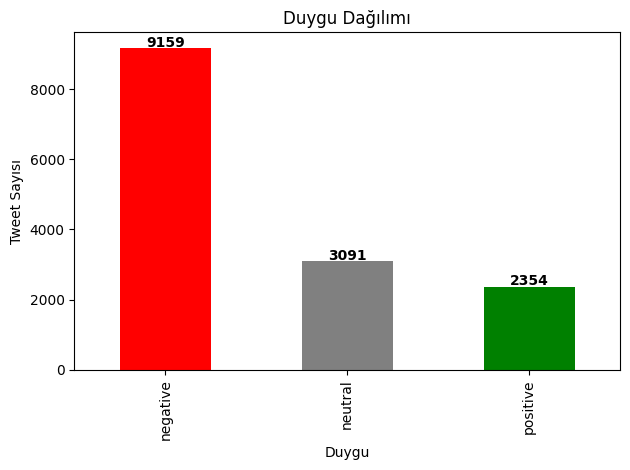

In [18]:
import matplotlib.pyplot as plt

# Duygu dağılımı (bar grafik)
duygu_sayilari = df['airline_sentiment'].value_counts()
ax = duygu_sayilari.plot(kind='bar', color=['red', 'gray', 'green'])

# Her barın üstüne adet yaz
for i, v in enumerate(duygu_sayilari):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.title('Duygu Dağılımı')
plt.xlabel('Duygu')
plt.ylabel('Tweet Sayısı')
plt.tight_layout()
plt.savefig('grafik1_duygu_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()

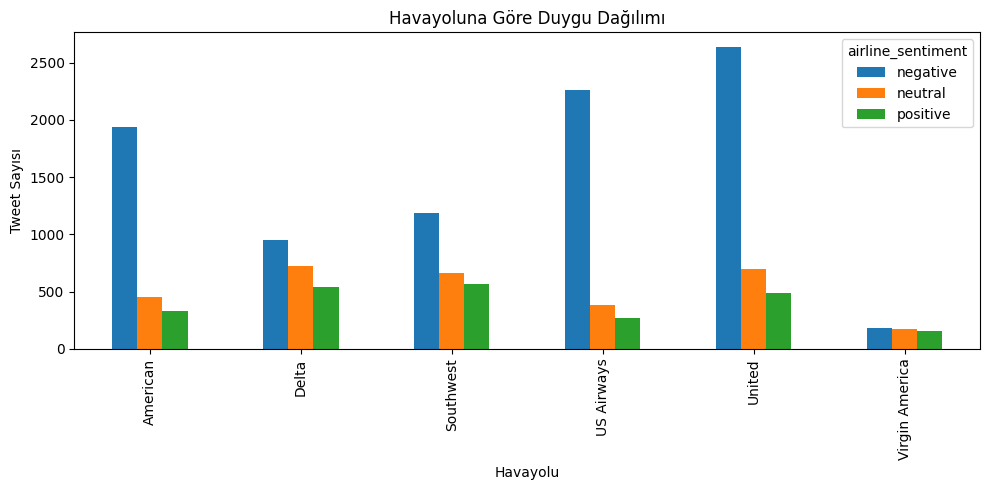

In [19]:
# 3. hücre - Havayoluna göre duygu dağılımı
df.groupby(['airline', 'airline_sentiment']).size().unstack().plot(kind='bar', figsize=(10,5))
plt.title('Havayoluna Göre Duygu Dağılımı')
plt.xlabel('Havayolu')
plt.ylabel('Tweet Sayısı')
plt.tight_layout()
plt.savefig('grafik2_havayolu_duygu.png', dpi=150, bbox_inches='tight')
plt.show()

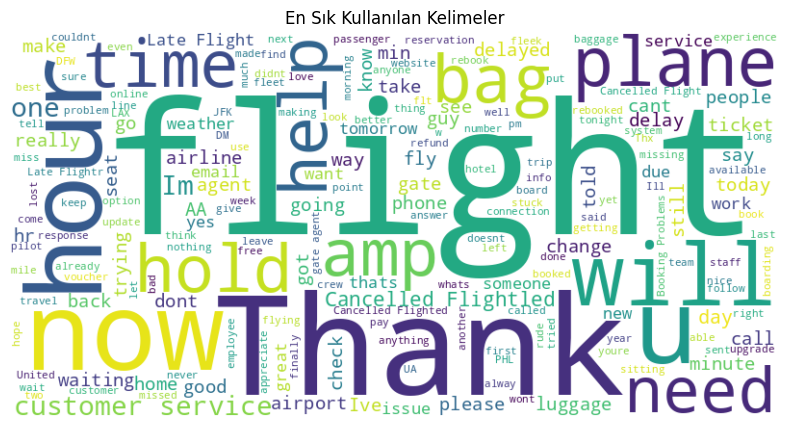

In [20]:
# 4. hücre - WordCloud
text = ' '.join(df['text'].dropna())
wc = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('En Sık Kullanılan Kelimeler')
plt.savefig('grafik3_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

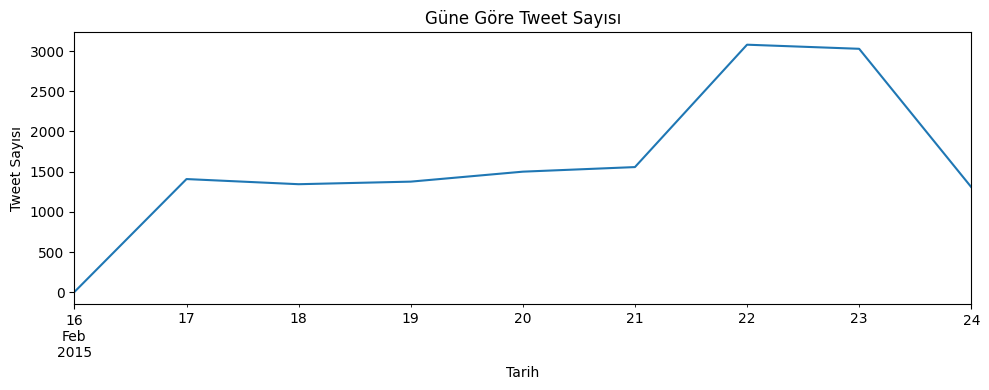

In [21]:
# 5. hücre - Zaman serisi
df['tweet_created'] = pd.to_datetime(df['tweet_created'])
df.set_index('tweet_created').resample('D').size().plot(figsize=(10,4))
plt.title('Güne Göre Tweet Sayısı')
plt.xlabel('Tarih')
plt.ylabel('Tweet Sayısı')
plt.tight_layout()
plt.savefig('grafik4_zaman_serisi.png', dpi=150, bbox_inches='tight')
plt.show()

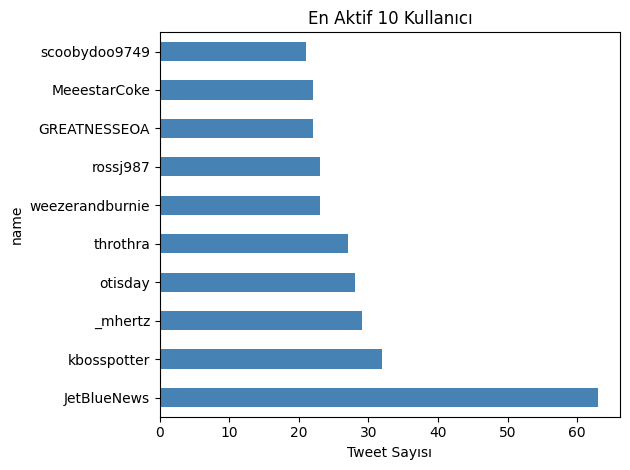

In [22]:
# 6. hücre - En aktif kullanıcılar
df['name'].value_counts().head(10).plot(kind='barh', color='steelblue')
plt.title('En Aktif 10 Kullanıcı')
plt.xlabel('Tweet Sayısı')
plt.tight_layout()
plt.savefig('grafik5_aktif_kullanici.png', dpi=150, bbox_inches='tight')
plt.show()